In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import pywt

## Часть 0. В поисках утраченного морлета


$$f _c=\omega_0 {\frac {1}{1-e^{-\omega_0 f _c}}}$$

Пример нерабочего способа вычисления центральной частоты

In [ ]:
def morlet_central_frequency(omega, max_iteration = 1000, total = 10e-7):
  fc = omega
  for _ in range(max_iteration):
    new_fc = float(omega) / float(-np.expm1(-omega * fc))
    if abs(new_fc - fc) < total:
      return new_fc
    fc = new_fc
  print('Для заданного числа итераций требуемая точность не достигнута')
  return fc


In [ ]:
fc = pywt.central_frequency("morl")
print(fc)

0.8125


In [ ]:
morlet_central_frequency(6)

6.000000000000002

### Рабочий вариант

Источники вдохновения - исходный код библиотек:

---


https://github.com/scipy/scipy/blob/v1.12.0/scipy/signal/_wavelets.py

https://github.com/PyWavelets/pywt/blob/main/pywt/_functions.py

In [ ]:
def morlet_function(t, omega):
  return math.pi ** (-0.25) * np.exp(-0.5 * t ** 2) * (np.exp(1j*omega * t) - np.exp(-0.5*omega * omega))

In [ ]:
from numpy.fft import fft
def get_morlet_central_frequency(morlet_values, total_time):
  index = np.argmax(abs(fft(morlet_values)[1:])) + 1
  print('fft index', index)
  fc = index/total_time
  return fc

def get_morlet_points(points_num, w0, scale):
  points = np.arange(0, points_num) - (points_num - 1)/2
  scaled_points = points/scale
  morlet_points = [morlet_function(t, w0) for t in scaled_points]
  return morlet_points

def get_scales(left_frequency, right_frequency, delta_t, fc, points_num=100):
  left_scale = fc/(delta_t*left_frequency)
  right_scale = fc/(delta_t*right_frequency)
  ln_left_scale= np.log(left_scale)
  ln_right_scale = np.log(right_scale)
  ln_scales = np.linspace(ln_left_scale, ln_right_scale, points_num)
  scales = np.exp(ln_scales)
  return scales

fft index 10
fc =  1.0101010101010102


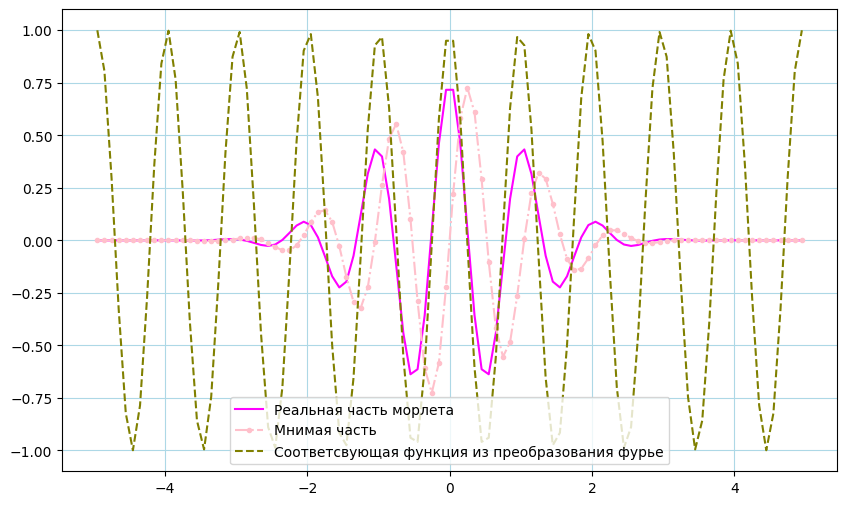

In [ ]:
n = 100
w0 = 6
scale = 10

points = np.arange(0, n) - (n - 1)/2
scaled_points = points/scale
morlet_values = get_morlet_points(n, w0, scale)
total_time = scaled_points[-1] - scaled_points[0]
fc = get_morlet_central_frequency(morlet_values, total_time)

sinusoid = np.exp(1j * 2*np.pi * fc * scaled_points)

print('fc = ', fc)
plt.figure(figsize=(10, 6))
plt.grid(color='lightblue')
plt.plot(scaled_points, np.real(morlet_values), color='magenta', label='Реальная часть морлета')
plt.plot(scaled_points, np.imag(morlet_values), '.-.', color='pink', label = 'Мнимая часть')
plt.plot(scaled_points, np.real(sinusoid), '--', color='olive', label='Соответсвующая функция из преобразования фурье')
plt.legend()


## Реализация CWT и обработка RR интервалов

In [ ]:
bands = {
    "HF": (0.15, 0.4),
    "LF": (0.04, 0.15),
    "VLF": (0.015, 0.04),
    # "ULF": (0.005, 0.015)
}

In [ ]:
delta_t = 0.25
fs = 1 / delta_t
left_interval_border = bands['VLF'][0]
right_interval_border = bands['HF'][1]
df = 0.005

In [ ]:
from scipy.interpolate import CubicSpline
def load_rr_intervals(filename):
  rr_intervals = pd.read_csv(filename).to_numpy(dtype=float)
  rr_intervals = rr_intervals/1000
  time = np.cumsum(rr_intervals)
  time = time - time[0]
  cubic_splie = CubicSpline(time, rr_intervals)
  time_interpolated = np.arange(time[0], time[-1], delta_t)
  rr_interpolated = [item[0] for item in cubic_splie(time_interpolated)]
  return rr_interpolated, time_interpolated

In [ ]:
from tqdm import tqdm
from scipy.signal import fftconvolve

def calculate_fc(w0):
  morlet_family_example = get_morlet_points(100, w0, 10)
  points = (np.arange(0, 100) - (100 - 1)/2)/10
  total_time = points[-1] - points[0]
  fc = get_morlet_central_frequency(morlet_family_example, total_time)
  return fc

def calculate_cwt(signal, w0, left_freq, right_freq, delta_t):
  fc = calculate_fc(w0)
  scales = get_scales(left_freq, right_freq, delta_t, fc)
  cwt_coefs = np.empty((len(scales), (len(signal))))

  for i, scale in tqdm(enumerate(scales)):
    morlet_points = get_morlet_points(len(signal), w0, scale)
    cwt_coefs[i] = fftconvolve(signal, morlet_points, mode='same')

  frequencies = fc/(delta_t*scales)
  delta_scales = np.diff(scales)
  delta_scales = delta_scales.tolist()
  delta_scales.append(delta_scales[-1])
  icwt_coefs = np.transpose(np.multiply(np.transpose(cwt_coefs), delta_scales/pow(scales,1.5)))
  return scales, cwt_coefs, icwt_coefs, frequencies

def calculate_bands_power(icwt_coefs, bands, frequencies):
  bands_power = {}
  for band_name in bands:
    left_index = np.argwhere(frequencies > bands[band_name][0])
    if len(left_index) == 0:
      left_index = 0
    else:
      left_index = left_index[0][0]

    right_index = np.argwhere(frequencies >= bands[band_name][1])
    if len(right_index) == 0:
      right_index = len(frequencies) - 1
    else:
      right_index = right_index[0][0]
    # print(left_index, right_index)
    bands_power[band_name] = sum(icwt_coefs[left_index:right_index])
  return bands_power


In [ ]:
def plot_cwt(ax, coefs, title):
  img = ax.imshow(
      np.abs(coefs),
      aspect='auto',
      cmap='gnuplot'
  )
  ax.set_xlabel('Time index')
  ax.set_ylabel('Scale index')
  plt.colorbar(img)
  ax.set_title(title)

In [ ]:
filename = '1_f.csv'
rr_interpolated, time_interpolated = load_rr_intervals(filename)
centered_rr = rr_interpolated - np.mean(rr_interpolated)

Сравнение CWT с разными частотами $w_0$ морлета

In [ ]:
fig = plt.figure(figsize=(20, 20))
axes = fig.subplots(4, 2).flatten()
w0s = np.arange(2, 26, 3)
for i, ax in enumerate(axes):
  scales, cwt_coefs, icwt_coefs, frequencies = calculate_cwt(centered_rr, w0s[i], left_interval_border, right_interval_border, delta_t)
  plot_cwt(ax, cwt_coefs, f'custom CWT morlet w0 = {w0s[i]}')

Output hidden; open in https://colab.research.google.com to view.

Оценка мощности компонент

In [ ]:
custom_scales, custom_cwt_coefs, custom_icwt_coefs, frequencies = calculate_cwt(centered_rr, 5, left_interval_border, right_interval_border, delta_t)

fft index 8


0it [00:00, ?it/s]/tmp/ipython-input-2343535487.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  cwt_coefs[i] = fftconvolve(signal, morlet_points, mode='same')
100it [00:01, 89.56it/s]


In [ ]:
custom_bands_power = calculate_bands_power(custom_icwt_coefs, bands, frequencies)

In [ ]:
def calculate_band_characteristics(bands_powers):
  HF = sum(abs(bands_powers['HF']))
  LF = sum(abs(bands_powers['LF']))
  VLF = sum(abs(bands_powers['VLF']))
  total = HF + LF + VLF
  HF_percent = HF/total * 100
  LF_percent = LF/total * 100
  VLF_percent = VLF/total * 100
  IVI = LF / HF
  return HF, LF, VLF, total, HF_percent, LF_percent, VLF_percent, IVI

In [ ]:
HF, LF, VLF, total, HF_percent, LF_percent, VLF_percent, IVI = calculate_band_characteristics(custom_bands_power)
print('Абсолютный HF:', HF)
print('Абсолютный LF:', LF)
print('Абсолютный VLF:', VLF)
print('Суммарная мощность:', total)
print('=====================================')
print(f'Относительный HF: {HF_percent:.3f}%')
print(f'Относительный LF: {LF_percent:.3f}%')
print(f'Относительный VLF: {VLF_percent:.3f}%')
print('=====================================')
print('Индекс вегетативного баланса:', IVI)

Абсолютный HF: 18.666970750353997
Абсолютный LF: 36.067496884027776
Абсолютный VLF: 54.90370749427894
Суммарная мощность: 109.63817512866072
Относительный HF: 17.026%
Относительный LF: 32.897%
Относительный VLF: 50.077%
Индекс вегетативного баланса: 1.9321558578723224


### CWT из библиотеки pywt

In [ ]:
import pywt
def pywt_calculate_cwt(signal, wavelet_type, left_freq, right_freq, delta_t):
  fc = pywt.central_frequency(wavelet_type)
  scales = get_scales(left_freq, right_freq, delta_t, fc)
  cwt_coefs, frq = pywt.cwt(signal, scales, wavelet_type)

  frequencies = fc/(delta_t*scales)
  delta_scales = np.diff(scales)
  delta_scales = delta_scales.tolist()
  delta_scales = np.append(delta_scales, delta_scales[-1])
  icwt_coefs = np.transpose(np.multiply(np.transpose(cwt_coefs), delta_scales/pow(scales,1.5)))
  return scales, cwt_coefs, icwt_coefs, frequencies

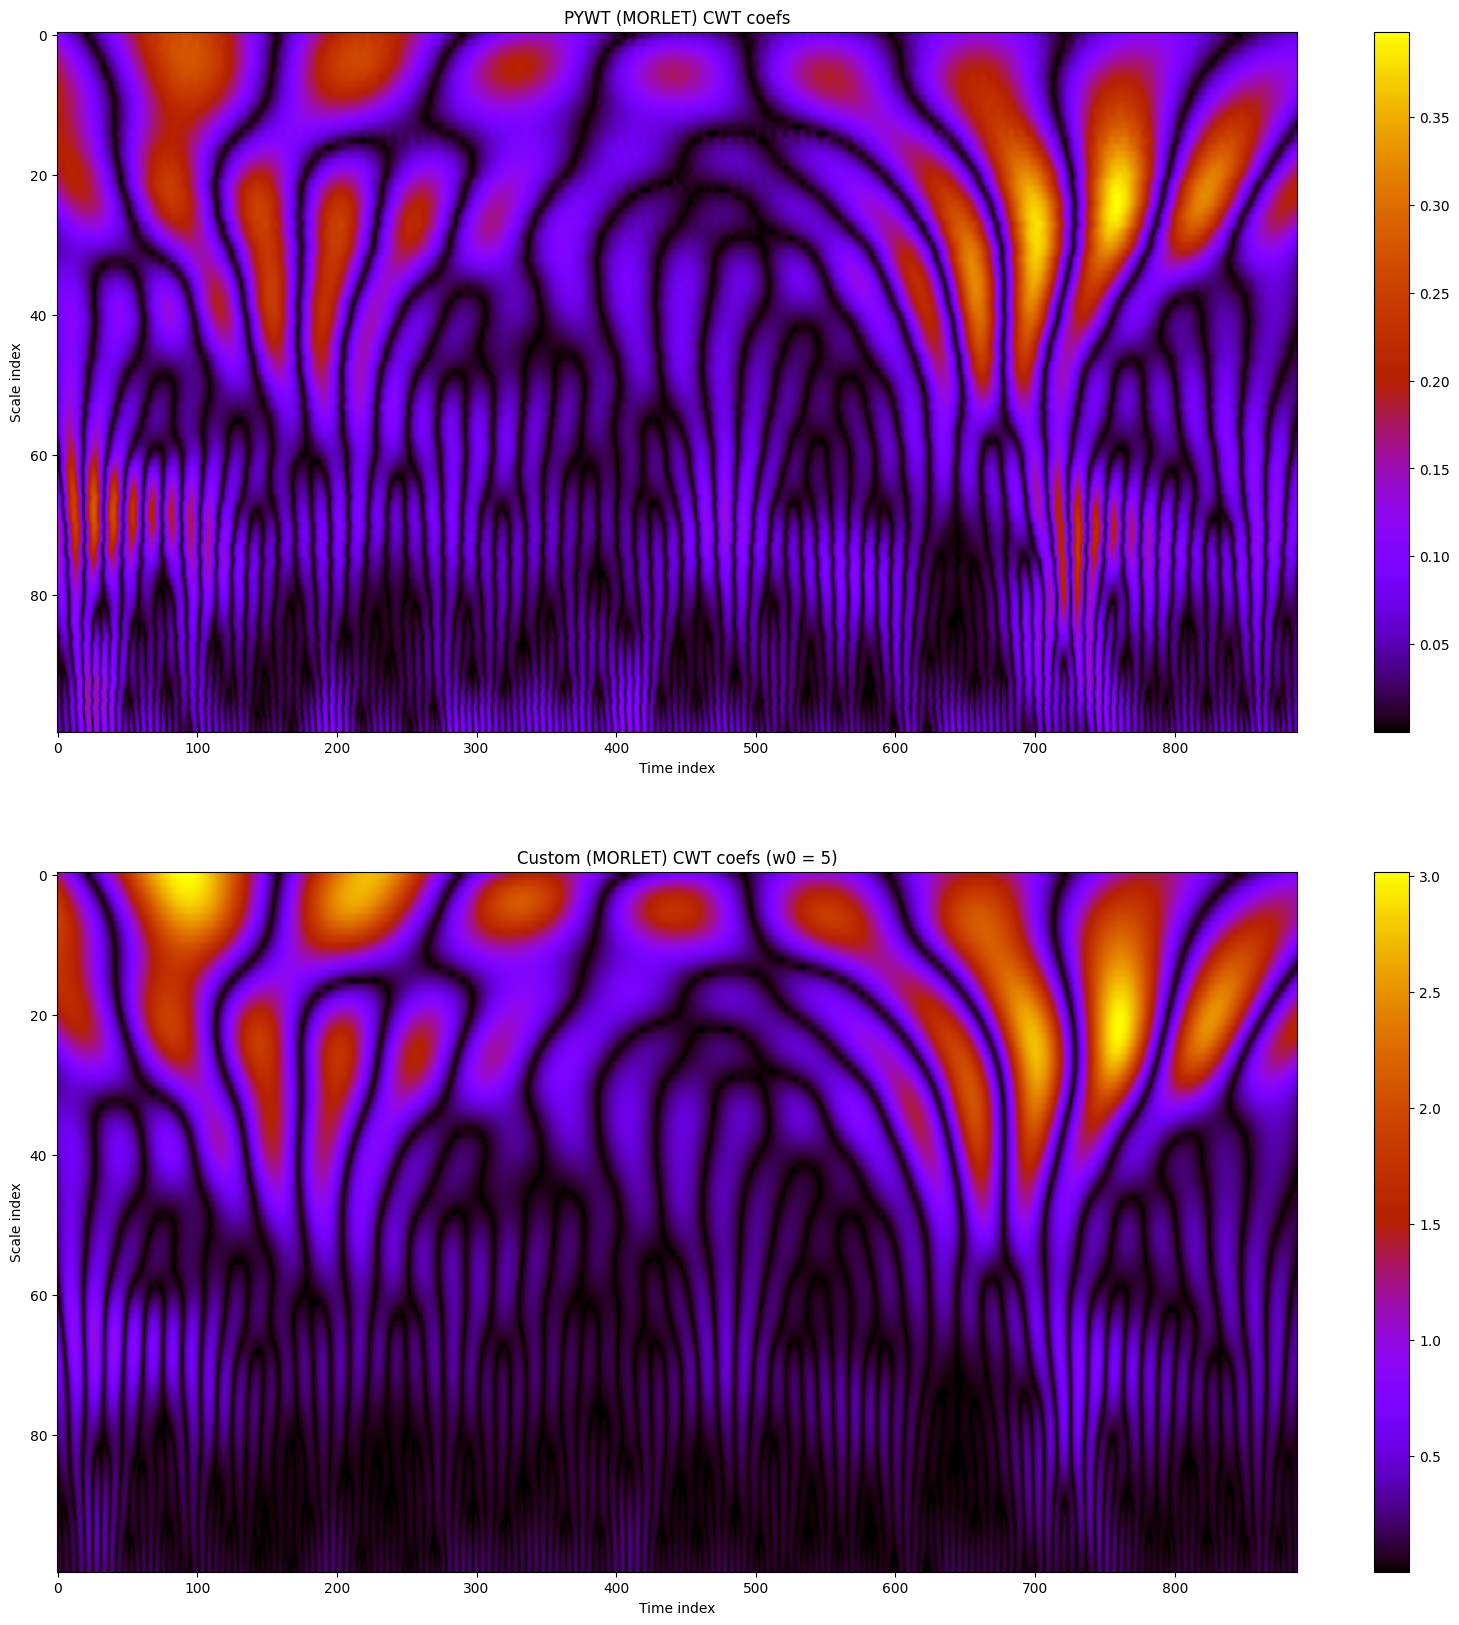

In [ ]:
pywt_scales, pywt_cwt_coefs, pywt_icwt_coefs, frequencies = pywt_calculate_cwt(centered_rr, 'morl', left_interval_border, right_interval_border, delta_t)
fig = plt.figure(figsize=(20, 20))
ax = fig.subplots(2, 1)
plot_cwt(ax[0], pywt_cwt_coefs, "PYWT (MORLET) CWT coefs")
plot_cwt(ax[1], custom_cwt_coefs, "Custom (MORLET) CWT coefs (w0 = 5)")

In [ ]:
pywt_bands_power = calculate_bands_power(pywt_icwt_coefs, bands, frequencies)

In [ ]:
HF, LF, VLF, total, HF_percent, LF_percent, VLF_percent, IVI = calculate_band_characteristics(pywt_bands_power)
print('Абсолютный HF (pywt):', HF)
print('Абсолютный LF (pywt):', LF)
print('Абсолютный VLF (pywt):', VLF)
print('Суммарная мощность (pywt):', total)
print('=====================================')
print(f'Относительный HF (pywt): {HF_percent:.3f}%')
print(f'Относительный LF (pywt): {LF_percent:.3f}%')
print(f'Относительный VLF (pywt): {VLF_percent:.3f}%')
print('=====================================')
print('Индекс вегетативного баланса (pywt):', IVI)

Абсолютный HF (pywt): 6.446328329614208
Абсолютный LF (pywt): 7.071703473386137
Абсолютный VLF (pywt): 6.406406205910501
Суммарная мощность (pywt): 19.924438008910844
Относительный HF (pywt): 32.354%
Относительный LF (pywt): 35.493%
Относительный VLF (pywt): 32.154%
Индекс вегетативного баланса (pywt): 1.0970126111788283


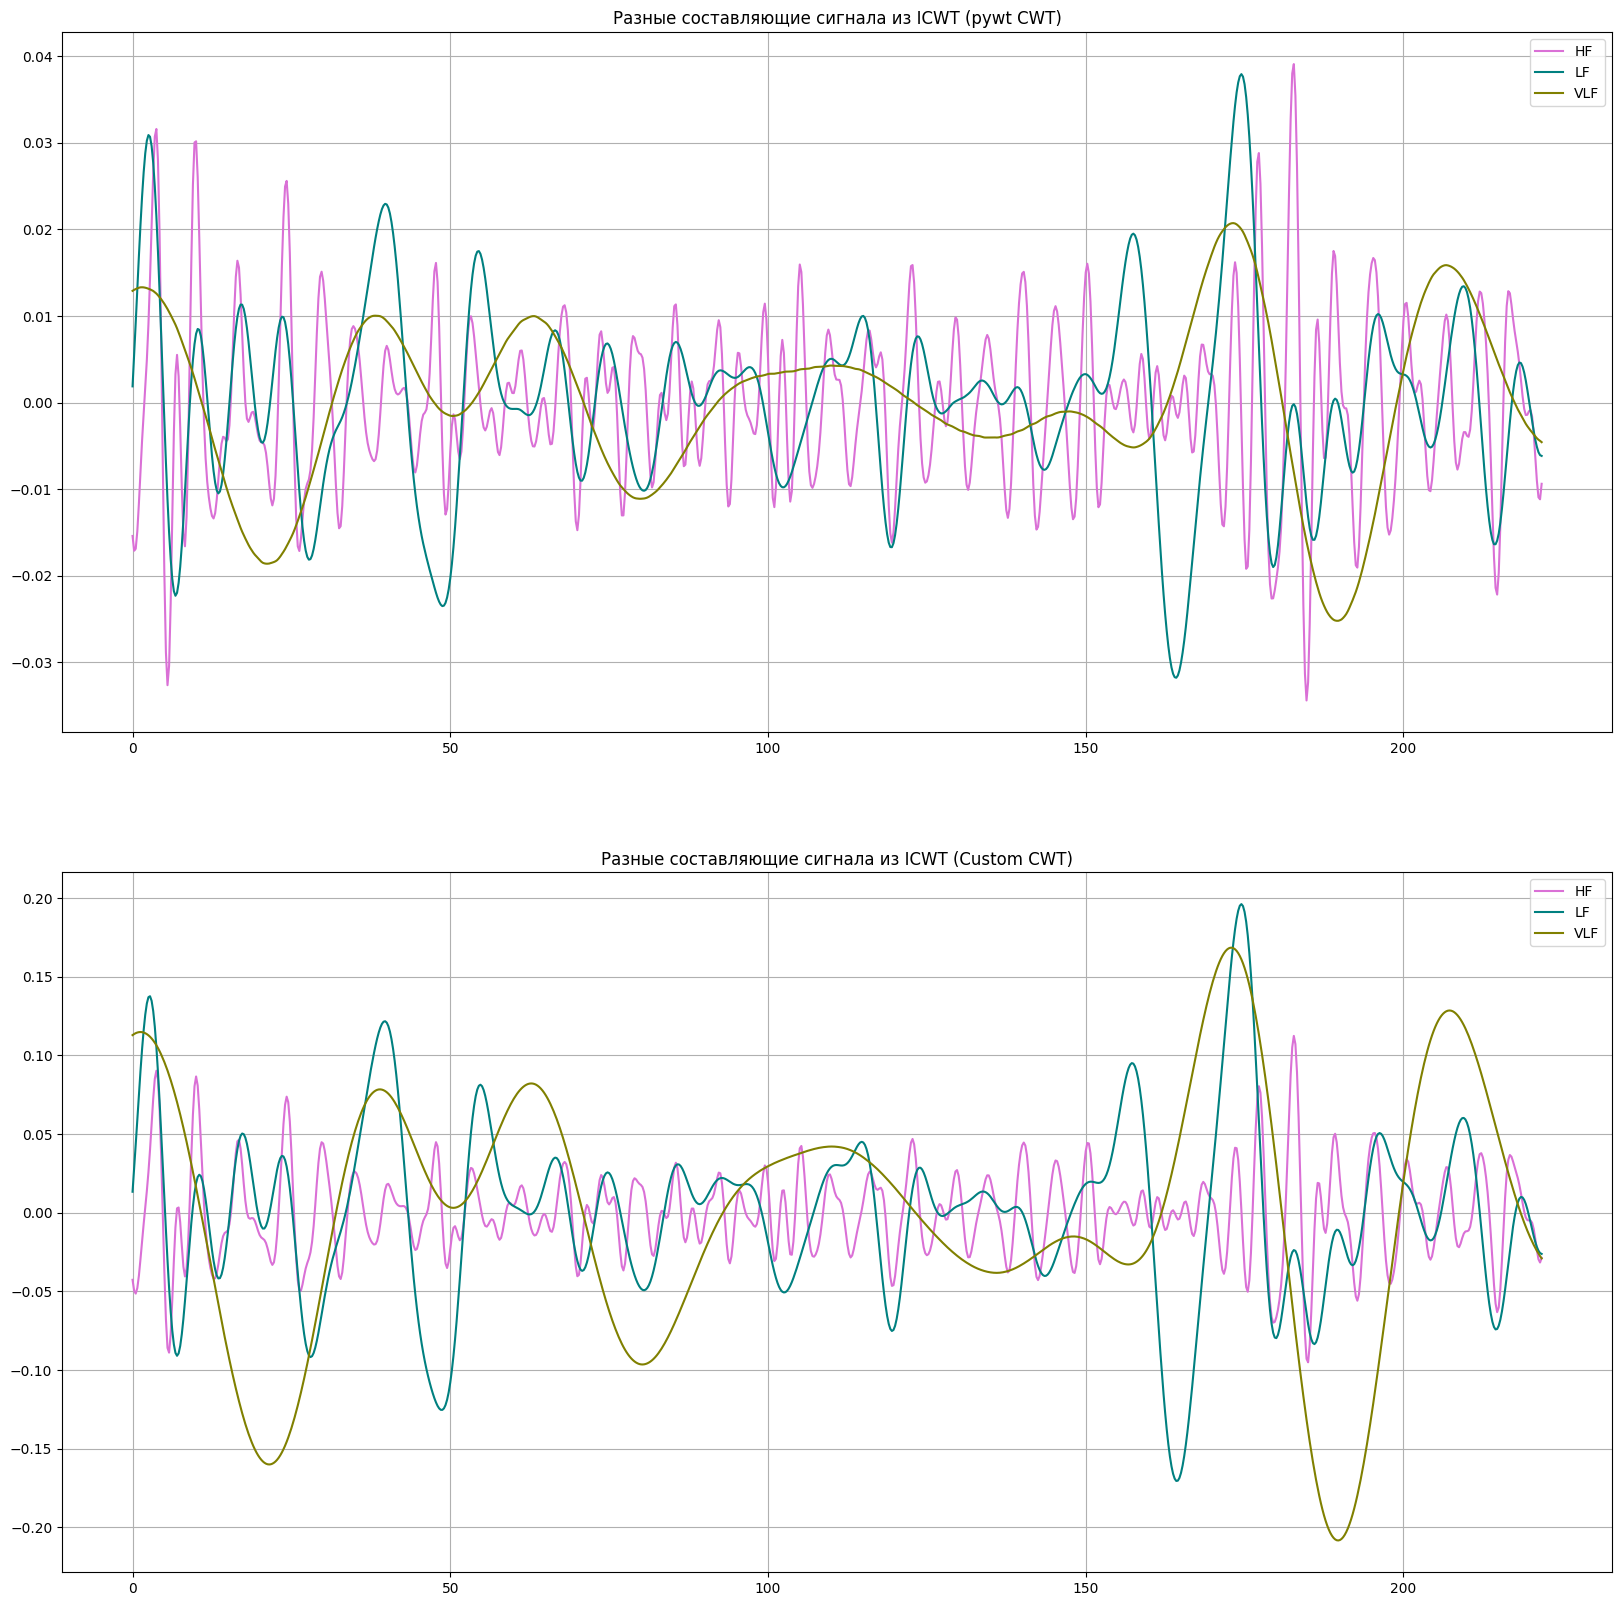

In [ ]:
# plt.figure(figsize=(10, 8))
fig = plt.figure(figsize=(20, 20))
ax = fig.subplots(2, 1)
ax[0].grid()
ax[0].plot(time_interpolated, pywt_bands_power['HF'], color='orchid', label = 'HF')
ax[0].plot(time_interpolated, pywt_bands_power['LF'], color='teal', label = 'LF')
ax[0].plot(time_interpolated, pywt_bands_power['VLF'], color='olive', label = 'VLF')
ax[0].set_title('Разные составляющие сигнала из ICWT (pywt CWT)')
ax[0].legend()

ax[1].grid()
ax[1].plot(time_interpolated, custom_bands_power['HF'], color='orchid', label = 'HF')
ax[1].plot(time_interpolated, custom_bands_power['LF'], color='teal', label = 'LF')
ax[1].plot(time_interpolated, custom_bands_power['VLF'], color='olive', label = 'VLF')
ax[1].set_title('Разные составляющие сигнала из ICWT (Custom CWT)')
ax[1].legend()

### Сравнение значений с преобразованием Фурье

In [ ]:
import math

def hanning_window(signal: np.array):
  N = len(signal)
  result_signal = np.zeros(N)
  for n in range(N):
    result_signal[n] = 0.5 * (1 - math.cos(2 * math.pi * n / N)) * signal[n]
  return result_signal

def discrete_fourier_transform(signal: np.array) -> np.array:
  N = len(signal)
  transformed_data = np.zeros(N, dtype=complex)
  for k in range(N):
    real = 0.0
    imag = 0.0
    for n in range(N):
      real += signal[n] * math.cos(-2 * math.pi * k * n/N)
      imag += signal[n] * math.sin(-2 * math.pi * k * n/N)
    transformed_data[k] = complex(real, imag)
  return transformed_data

def get_frequences_in_hz(N: int, f0: float):
  return [k  * f0 for k in range(N)]

def calculate_psd(dft_data: np.array) -> np.array:
  N = len(dft_data)
  psd = np.zeros(N)
  for k in range(N):
    psd[k] = (dft_data[k].real * dft_data[k].real + dft_data[k].imag * dft_data[k].imag) / (N * N)
  return psd

In [ ]:
class SpectralAnalysis():
  def __init__(self):
    self.delta_t = 0.25
    self.bands = {
      "HF": (0.15, 0.4),
      "LF": (0.04, 0.15),
      "VLF": (0.015, 0.04),
      "ULF": (0.005, 0.015)
    }
    self.ylim = (0, 18)
    self.xlim = (-0.01, 0.6)
    self.image_size = (12, 6)

    self.rr_intervals = []
    self.times = []
    self.time_intervals = []
    self.interpolated_rr = []
    self.transformed_rr = []
    self.fs = 0
    self.f0 = 0
    self.hight_frequency_border = 0
    self.frequences = []
    self.psd_df = pd.DataFrame()
    self.masks = []
    self.hf_power_min = 0
    self.hf_power_max = 0
    self.lf_power_min = 0
    self.lf_power_max = 0
    self.vlf_power_min = 0
    self.vlf_power_max = 0
    self.ulf_power_min = 0
    self.ulf_power_max = 0
    self.hf_power = 0
    self.lf_power = 0
    self.vlf_power = 0
    self.ulf_power = 0
    self.total_power = 0
    self.hf_percent_power = 0
    self.lf_percent_power = 0
    self.vlf_percent_power =0
    self.ulf_percent_power =0
    self.IC = 0
    self.IVI = 0
    self.ISCA = 0

  def calculate_metrics(self, rr_intervals: list[int], times):
    self.rr_intervals = rr_intervals.copy()
    self.times = times
    self.time_intervals = np.arange(0, max(times), self.delta_t)
    interpolation_function = CubicSpline(times, self.rr_intervals)
    interpolated_values = interpolation_function(self.time_intervals)
    self.interpolated_rr = interpolated_values
    after_hanning_values = hanning_window(self.interpolated_rr)
    self.transformed_rr = discrete_fourier_transform(after_hanning_values)
    self.fs = 1 / self.delta_t
    self.f0 = self.fs / len(self.interpolated_rr)
    self.hight_frequency_border = self.fs / 2
    frequences = get_frequences_in_hz(len(self.transformed_rr), self.f0)
    psd = calculate_psd(self.transformed_rr)
    self.psd_df = self._process_psd(psd, frequences)
    self._calculate_masks()
    self._calculate_band_power()

  def _process_psd(self, psd: np.array, frequences: np.array):
    psd_df = pd.DataFrame({"PSD": psd, "frequences": frequences})
    psd_df = psd_df[psd_df['frequences'] <= self.hight_frequency_border]
    psd_df['PSD'] *= 2
    return psd_df

  def _calculate_masks(self):
    masks = []
    for key in self.bands:
      mask = (self.psd_df['frequences'] >= self.bands[key][0]) & (self.psd_df['frequences'] < self.bands[key][1])
      masks.append(mask)
    self.masks = masks

  def _calculate_band_power(self, include_ULF: bool = False):
    self.hf_power_min = self.psd_df['PSD'][self.masks[0]].min()
    self.hf_power_max = self.psd_df['PSD'][self.masks[0]].max()
    self.lf_power_min = self.psd_df['PSD'][self.masks[1]].min()
    self.lf_power_max = self.psd_df['PSD'][self.masks[1]].max()
    self.vlf_power_min = self.psd_df['PSD'][self.masks[2]].min()
    self.vlf_power_max = self.psd_df['PSD'][self.masks[2]].max()
    self.ulf_power_min = self.psd_df['PSD'][self.masks[3]].min()
    self.ulf_power_max = self.psd_df['PSD'][self.masks[3]].max()
    self.hf_power = self.psd_df['PSD'][self.masks[0]].sum()
    self.lf_power = self.psd_df['PSD'][self.masks[1]].sum()
    self.vlf_power = self.psd_df['PSD'][self.masks[2]].sum()
    self.ulf_power = self.psd_df['PSD'][self.masks[3]].sum()
    if include_ULF == True:
      self.total_power = self.hf_power + self.lf_power + self.vlf_power + self.ulf_power
      self.ulf_percent_power = self.ulf_power * 100/self.total_power
    else:
      self.total_power = self.hf_power + self.lf_power + self.vlf_power
      self.ulf_percent_power = 0
    self.hf_percent_power = self.hf_power * 100/self.total_power
    self.lf_percent_power = self.lf_power * 100/self.total_power
    self.vlf_percent_power = self.vlf_power * 100/self.total_power
    self.ylim = (0, max(self.hf_power_max, self.lf_power_max, self.vlf_power_max))
    self.IC = (self.vlf_power + self.lf_power) / self.hf_power
    self.IVI = self.lf_power / self.hf_power
    self.ISCA = self.lf_power / self.vlf_power

  def plot_cardiac_rhythmogram(self):
    plt.figure(figsize=self.image_size)
    plt.grid(color='blue', linewidth = 0.2)
    plt.xlabel('Длительность измерений, c.')
    plt.ylabel('Кардиоинтервалы, мc.')
    plt.title('Кардиоритмограмма')
    plt.plot(self.times, self.rr_intervals, color='pink')
    plt.scatter(self.times, self.rr_intervals, color='red', s=25)

  def plot_spectrogram(self):
    plt.figure(figsize=self.image_size)
    plt.grid(color='blue', linewidth = 0.2)
    plt.xlabel('Частоты, Гц.')
    plt.ylabel('Спектральная плотность мощности, мc^2/Гц')
    plt.title('Спектрограмма')
    plt.ylim(self.ylim)
    plt.xlim(self.xlim)

    plt.vlines([self.bands['HF'][1], self.bands['LF'][1], self.bands['VLF'][1],
                self.bands['ULF'][1]], self.ylim[0], self.ylim[1], color='peru',
                linestyles='--')

    plt.plot(self.psd_df['frequences'], self.psd_df['PSD'], color='slateblue', label='Other',)
    plt.plot(self.psd_df['frequences'][self.masks[0]], self.psd_df['PSD'][self.masks[0]], color='orchid', label='HF')
    plt.plot(self.psd_df['frequences'][self.masks[1]], self.psd_df['PSD'][self.masks[1]], color='teal', label='LF')
    plt.plot(self.psd_df['frequences'][self.masks[2]], self.psd_df['PSD'][self.masks[2]], color='olive', label='VLF')
    plt.plot(self.psd_df['frequences'][self.masks[3]], self.psd_df['PSD'][self.masks[3]], color='coral', label='ULF')

    plt.legend()

  def print_values(self):
    print("Частота дискретизации:", self.fs)
    print("Верхняя граница частот:", self.hight_frequency_border)
    print("Нижняя граница частот:", self.f0)
    print(f"Мощность HF минимальная: {self.hf_power_min}, максимальная: {self.hf_power_max}")
    print(f"Мощность LF минимальная: {self.lf_power_min}, максимальная: {self.lf_power_max}")
    print(f"Мощность VLF минимальная: {self.vlf_power_min}, максимальная: {self.vlf_power_max}")
    print(f"Мощность ULF минимальная: {self.ulf_power_min}, максимальная: {self.ulf_power_max}")
    print("Суммарная мощность HF:", self.hf_power)
    print("Суммарная мощность LF:", self.lf_power)
    print("Суммарная мощность VLF:", self.vlf_power)
    print("Суммарная мощность ULF:", self.ulf_power)
    print("Суммарная мощность:", self.total_power)
    print(f"Относительная мощность HF: {self.hf_percent_power:.2f}%")
    print(f"Относительная мощность LF: {self.lf_percent_power:.2f}%")
    print(f"Относительная мощность VLF: {self.vlf_percent_power:.2f}%")
    print(f"Относительная мощность ULF: {self.ulf_percent_power:.2f}%")
    print("Индекс централизации ИЦ", self.IC)
    print("Индекс вагосимпатического взаимодействия ИВВ", self.IVI)
    print("Индекс активации подкорковых нервных центров ИАП", self.ISCA)


In [ ]:
spectral_analysis = SpectralAnalysis()
spectral_analysis.calculate_metrics(centered_rr, time_interpolated)
spectral_analysis.print_values()

Частота дискретизации: 4.0
Верхняя граница частот: 2.0
Нижняя граница частот: 0.004509582863585118
Мощность HF минимальная: 1.5753758950122027e-08, максимальная: 9.978616205408888e-06
Мощность LF минимальная: 9.520780995795638e-08, максимальная: 1.1669261327282659e-05
Мощность VLF минимальная: 5.984985232005909e-08, максимальная: 1.7047645141824404e-05
Мощность ULF минимальная: 1.3733861541210299e-07, максимальная: 1.0587571243244012e-05
Суммарная мощность HF: 6.77176316560047e-05
Суммарная мощность LF: 6.923998771324894e-05
Суммарная мощность VLF: 3.829350062471225e-05
Суммарная мощность ULF: 1.0724909858656116e-05
Суммарная мощность: 0.0001752511199939659
Относительная мощность HF: 38.64%
Относительная мощность LF: 39.51%
Относительная мощность VLF: 21.85%
Относительная мощность ULF: 0.00%
Индекс централизации ИЦ 1.5879688303958266
Индекс вагосимпатического взаимодействия ИВВ 1.022480940635632
Индекс активации подкорковых нервных центров ИАП 1.808139412267933


### Выводы

Значения согласуются с полученными с помщью pywt CWT

Индекс вегетативного баланса

custom CWT: 1.932

pywt CWT: 1.097

DFT: 1.022

### Сравнение других вейвлетов

In [ ]:
counter = 0
wavelist = pywt.wavelist()
cwt_wavelets = []
for wavelet in wavelist:
  try:
    scales, cwt_coefs, icwt_coefs, frequencies = pywt_calculate_cwt(centered_rr, wavelet, left_interval_border, right_interval_border, delta_t)
    counter+=1
    cwt_wavelets.append(wavelet)
  except Exception:
    pass
# fig = plt.figure(figsize=(20, 20))
# ax = fig.subplots(2, 1)
# plot_cwt(ax[0], cwt_coefs, "PYWT (MORLET) CWT coefs")
# plot_cwt(ax[1], custom_cwt_coefs, "Custom (MORLET) CWT coefs (w0 = 5)")

/usr/local/lib/python3.12/dist-packages/pywt/_functions.py:141: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)
/usr/local/lib/python3.12/dist-packages/pywt/_cwt.py:113: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)
/usr/local/lib/python3.12/dist-packages/pywt/_functions.py:141: FutureWarning: Wavelets of family fbsp, without parameters specified in the name are deprecated.  The name should fo

In [ ]:
cwt_wavelets.append(f'shan{left_interval_border}-{right_interval_border}')
cwt_wavelets.append(f'fbsp2-{left_interval_border}-{right_interval_border}')
cwt_wavelets.append(f'cmor{left_interval_border}-{right_interval_border}')

In [ ]:
fig = plt.figure(figsize=(25, 40))
axes = fig.subplots(8, 3).flatten()
result = {
    'wavelet': [],
    'HF': [],
    'LF': [],
    'VLF': [],
    'total': [],
    'HF_percent': [],
    'LF_percent': [],
    'VLF_percent': [],
    'IVI': []
}
for i, ax in enumerate(axes):
  wavelet = cwt_wavelets[i]
  scales, cwt_coefs, icwt_coefs, frequencies = pywt_calculate_cwt(centered_rr, wavelet, left_interval_border, right_interval_border, delta_t)
  plot_cwt(ax, cwt_coefs, f"{wavelet}")

  bands_power = calculate_bands_power(icwt_coefs, bands, frequencies)
  HF, LF, VLF, total, HF_percent, LF_percent, VLF_percent, IVI = calculate_band_characteristics(bands_power)
  result['wavelet'].append(wavelet)
  result['HF'].append(HF)
  result['LF'].append(LF)
  result['VLF'].append(VLF)
  result['total'].append(total)
  result['HF_percent'].append(HF_percent)
  result['LF_percent'].append(LF_percent)
  result['VLF_percent'].append(VLF_percent)
  result['IVI'].append(IVI)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
bands_power_df = pd.DataFrame(result)

In [ ]:
bands_power_df.sort_values(by=['IVI'])

,wavelet,HF,LF,VLF,total,HF_percent,LF_percent,VLF_percent,IVI
6,cgau7,8.846568,9.697337,8.555435,27.099340,32.644956,35.784404,31.570639,1.096169
19,morl,6.446328,7.071703,6.406406,19.924438,32.353878,35.492612,32.153510,1.097013
16,gaus7,8.709340,9.568775,8.673411,26.951526,32.314831,35.503647,32.181522,1.098680
15,gaus6,9.426611,10.383017,8.734700,28.544329,33.024463,36.375063,30.600475,1.101458
4,cgau5,10.056028,11.138857,9.736042,30.930926,32.511240,36.012038,31.476722,1.107680
14,gaus5,10.045783,11.147420,9.637443,30.830646,32.583757,36.156947,31.259296,1.109662
23,cmor0.015-0.4,27.338128,30.545242,17.241554,75.124924,36.390224,40.659265,22.950511,1.117313
2,cgau3,12.131914,13.645430,10.930729,36.708073,33.049715,37.172832,29.777453,1.124755
22,fbsp2-0.015-0.4,2.776938,3.126286,3.072864,8.976089,30.937063,34.829048,34.233889,1.125803
21,shan0.015-0.4,2.767113,3.117786,3.072694,8.957593,30.891261,34.806067,34.302672,1.126729
